In [1]:
import scanpy as sc
import anndata as ad


In [2]:

adata1=sc.read_loom('Dataset1_full.loom') 
adata1.obs_names=adata1.obs.obs_names
adata1.var_names=adata1.var.gene_name

C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:

adata2=sc.read_loom('Dataset2_full.loom') 
adata2.obs_names=adata2.obs.obs_names
adata2.var_names=adata2.var.gene_name

C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [4]:

# Keep only shared genes
common_genes = adata1.var_names.intersection(adata2.var_names)

adata1 = adata1[:, common_genes].copy()
adata2 = adata2[:, common_genes].copy()

# Add batch labels
adata1.obs["batch"] = "dataset1"
adata2.obs["batch"] = "dataset2"

# Concatenate
adata = ad.concat(
    [adata1, adata2],
    label="dataset",
    keys=["dataset1", "dataset2"],
    join="inner",
)

In [5]:
import bbknn

# concatenate datasets
adata = ad.concat([adata1, adata2], label="batch", keys=["dataset1", "dataset2"])

#sc.pp.scale(adata)
sc.tl.pca(adata)

bbknn.bbknn(adata, batch_key="batch")
#sc.pp.neighbors(adata)
sc.tl.umap(adata)

In [6]:
adata.obs.loc[adata.obs.Disease=='type II diabetes', 'Disease']='T2D'
adata.obs.Disease=adata.obs.Disease.astype(str)

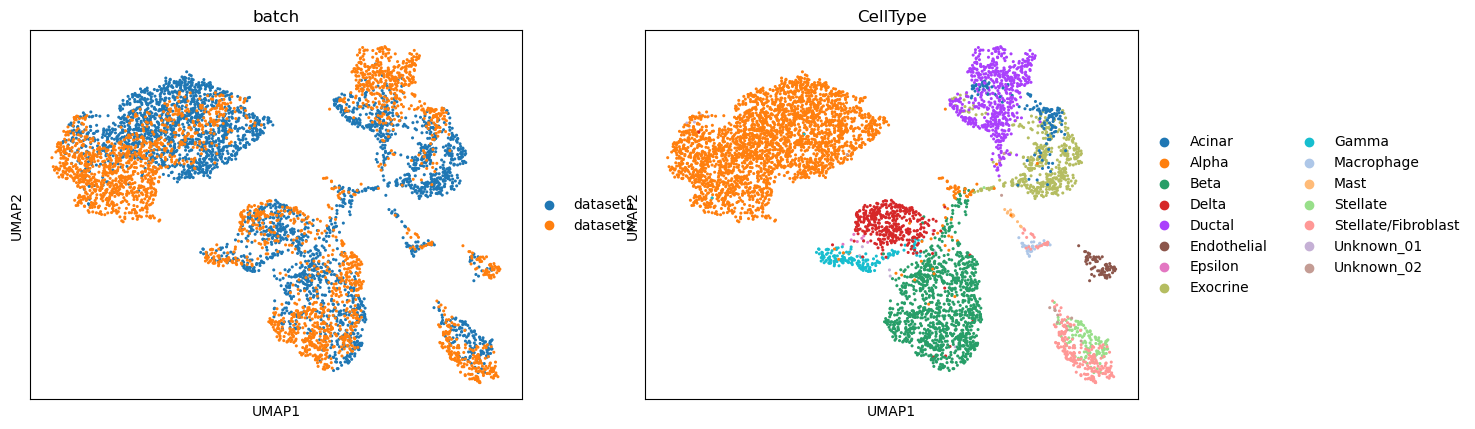

In [7]:
sc.pl.umap(adata,color=['batch','CellType'])

In [8]:
# 7. Cluster the cells
sc.tl.leiden(adata, resolution=0.5)



C:\Users\Leo\AppData\Local\Temp\ipykernel_42784\2500828949.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


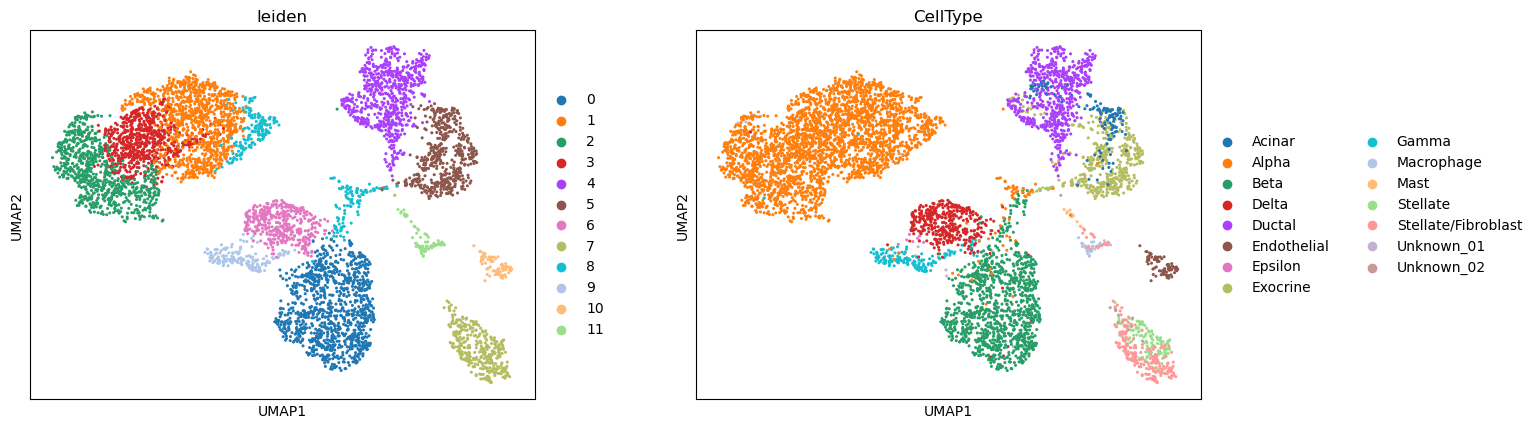

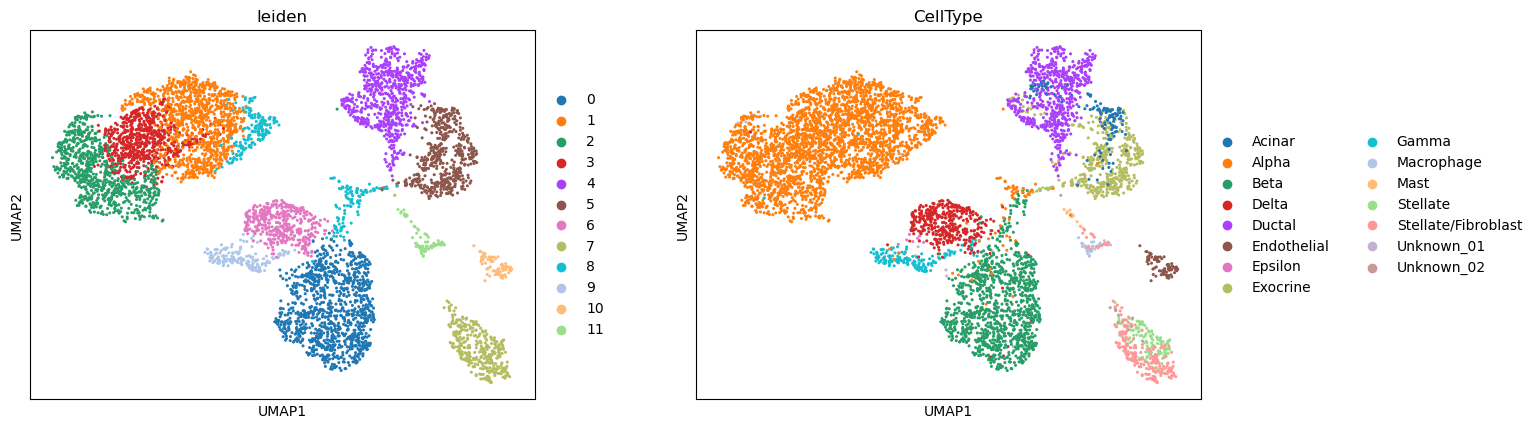

In [9]:
# 8. Visualize
sc.pl.umap(adata, color=['leiden', 'CellType'], save='Integration1.png', wspace=0.2)
sc.pl.umap(adata, color=['leiden','CellType'], save='Integration1.svg', wspace=0.2)

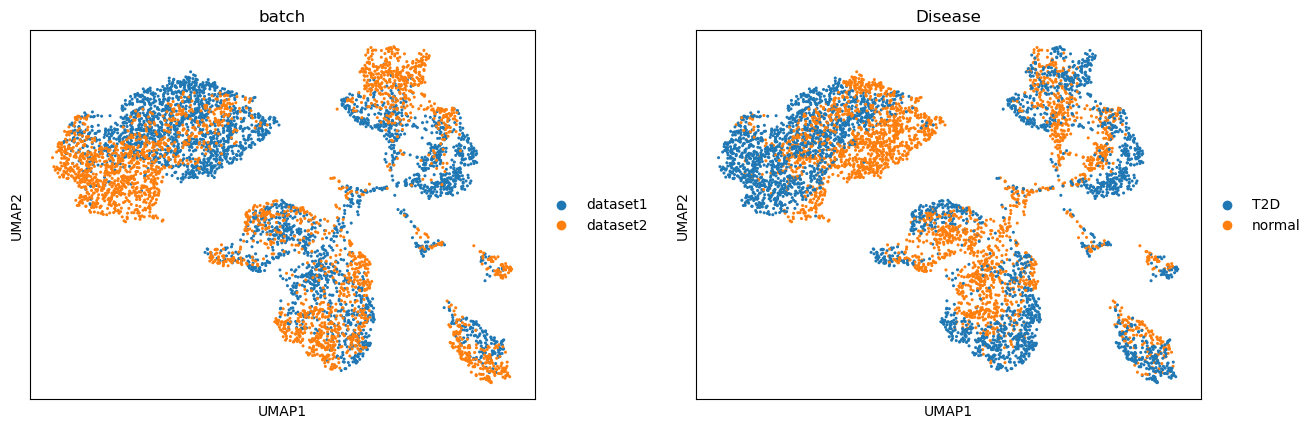

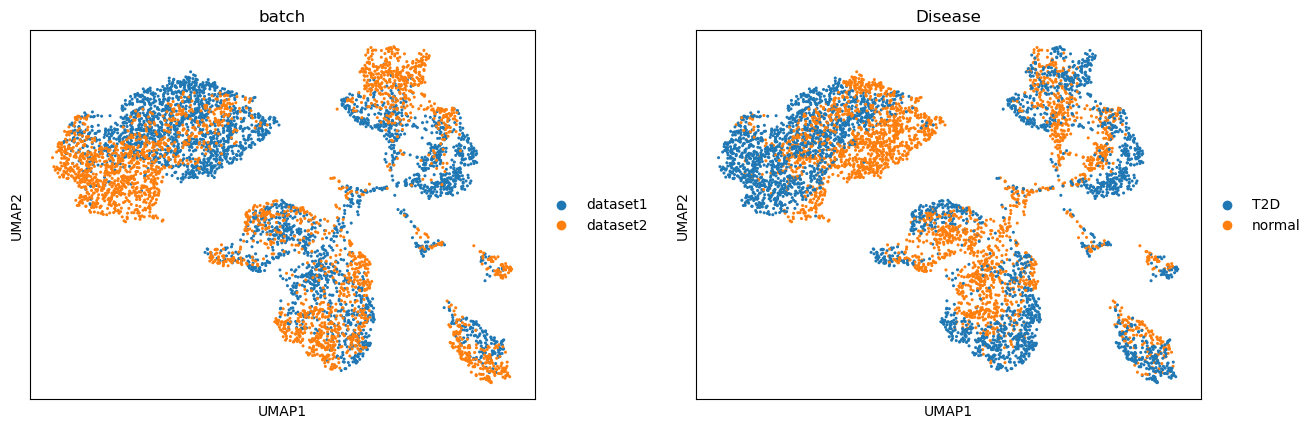

In [10]:
sc.pl.umap(adata, color=['batch','Disease'], save='Integration2.svg' , wspace=0.2)
sc.pl.umap(adata, color=['batch','Disease'], save='Integration2.png' , wspace=0.2)

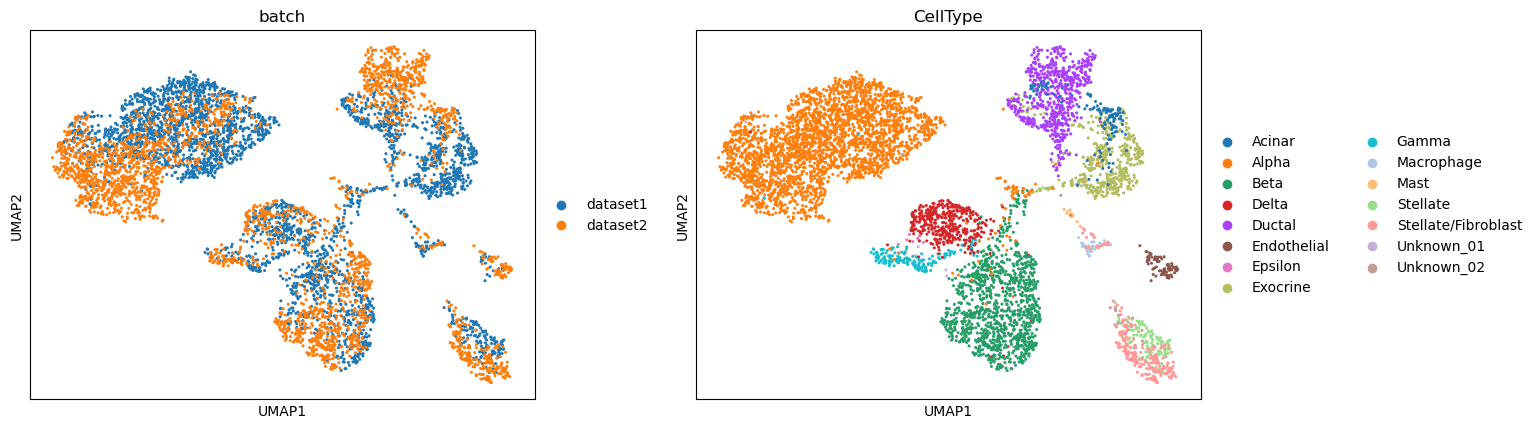

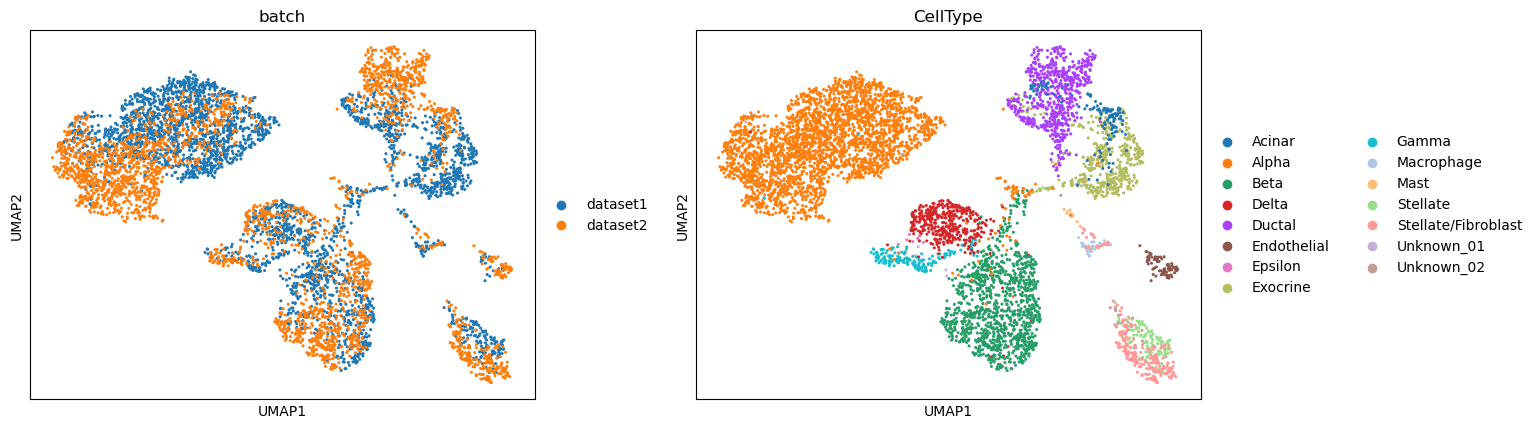

In [11]:
sc.pl.umap(adata, color=['batch','CellType'], save='Integration3.svg' , wspace=0.2)
sc.pl.umap(adata, color=['batch','CellType'], save='Integration3.png' , wspace=0.2)

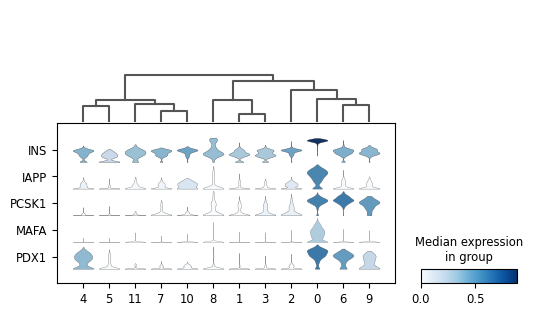

In [12]:
sc.pl.stacked_violin(adata, ['INS','IAPP','PCSK1','MAFA','PDX1'], groupby='leiden', dendrogram=True,  standard_scale='var', swap_axes=True, save='Beta_markers.svg')

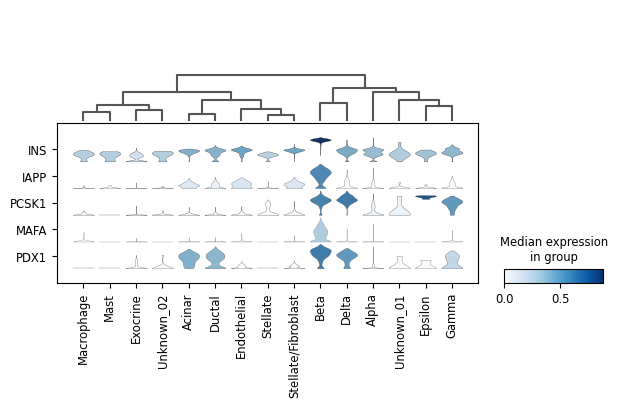

In [13]:
sc.pl.stacked_violin(adata, ['INS','IAPP','PCSK1','MAFA','PDX1'], groupby='CellType', dendrogram=True,  standard_scale='var', swap_axes=True, save='Beta_markers.svg')

In [14]:
cell_type_map = {
    "0": "Alpha",
    "1": "Beta",
    "2": "Alpha",
    "3": "Ductal",
    "4": "Exocrine",
    "5": "Alpha",
    "6": "Delta",
    "7": "Delta",
    "8": "Mixed"
}

#adata.obs["CellType"] = adata.obs["leiden"].map(cell_type_map)

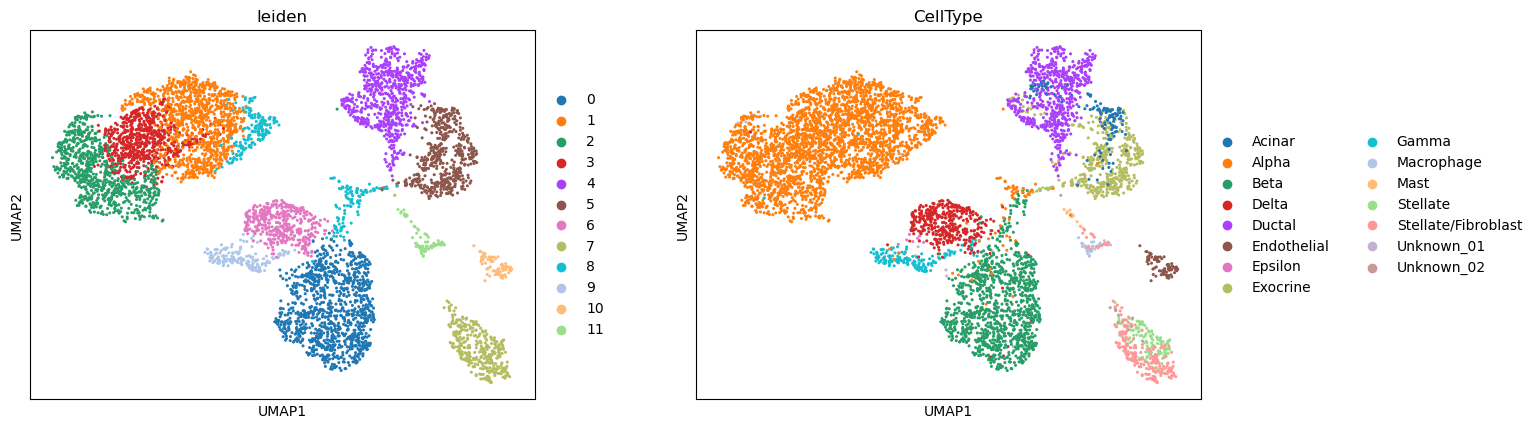

In [15]:
sc.pl.umap(adata, color=['leiden', 'CellType'],wspace=0.2)


In [16]:
adata.write_loom('Integrated_full.loom', write_obsm_varm=True) 

In [17]:
# Save betas only
betas=adata[adata.obs['CellType'] == 'Beta'].copy()

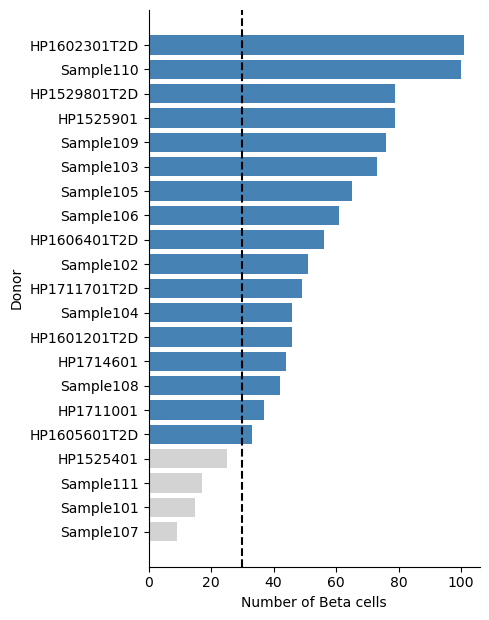

In [18]:
import matplotlib.pyplot as plt

# Count cells per donor
donor_counts = betas.obs["Donor"].value_counts().sort_values()

# Gray donors with <30 cells
colors = ["lightgray" if n < 30 else "steelblue" for n in donor_counts]

fig, ax = plt.subplots(figsize=(5, max(6, len(donor_counts) * 0.3)))

ax.barh(
    donor_counts.index.astype(str),
    donor_counts.values,
    color=colors
)

# Threshold
ax.axvline(
    30,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax.set_xlabel("Number of Beta cells")
ax.set_ylabel("Donor")
#ax.set_title("Beta cells per donor")

# Despine
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.savefig('Figure1/Figure1_beta_cells_per_donor.svg')
plt.show()

In [19]:
# Donors with at least 30 cells
keep_donors = betas.obs["Donor"].value_counts().loc[lambda x: x >= 30].index

# Filter AnnData
betas = betas[betas.obs["Donor"].isin(keep_donors)].copy()

In [20]:
betas

AnnData object with n_obs × n_vars = 1038 × 12727
    obs: 'CellType', 'Disease', 'Donor', 'obs_names', 'batch', 'leiden'
    uns: 'pca', 'neighbors', 'umap', 'batch_colors', 'CellType_colors', 'leiden', 'leiden_colors', 'Disease_colors', 'dendrogram_leiden', 'dendrogram_CellType'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [21]:
betas.write_loom('Integrated_betas.loom', write_obsm_varm=True) 

In [22]:
len(betas.obs.Donor.unique())

17

In [23]:
betas.obs[['Donor','batch','Disease']].drop_duplicates()

,Donor,batch,Disease
obs_names,,,
351,Sample110,dataset1,T2D
352,Sample102,dataset1,normal
358,Sample108,dataset1,T2D
369,Sample109,dataset1,T2D
370,Sample103,dataset1,normal
391,Sample105,dataset1,normal
393,Sample106,dataset1,normal
397,Sample104,dataset1,normal
HP1525901_A14,HP1525901,dataset2,normal


In [24]:
betas.obs[['Donor','batch','Disease']].value_counts()

Donor         batch     Disease
HP1602301T2D  dataset2  T2D        101
Sample110     dataset1  T2D        100
HP1525901     dataset2  normal      79
HP1529801T2D  dataset2  T2D         79
Sample109     dataset1  T2D         76
Sample103     dataset1  normal      73
Sample105     dataset1  normal      65
Sample106     dataset1  normal      61
HP1606401T2D  dataset2  T2D         56
Sample102     dataset1  normal      51
HP1711701T2D  dataset2  T2D         49
Sample104     dataset1  normal      46
HP1601201T2D  dataset2  T2D         46
HP1714601     dataset2  normal      44
Sample108     dataset1  T2D         42
HP1711001     dataset2  normal      37
HP1605601T2D  dataset2  T2D         33
Name: count, dtype: int64

In [29]:
import pandas as pd